In [1]:
import tensorflow as tf

In [2]:
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageStat, ImageOps
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, fbeta_score, accuracy_score

import warnings
warnings.filterwarnings('ignore')

Check Dataset Distribution

In [3]:
import os

dataset_path = "tea_dataset"

for folder in os.listdir(dataset_path):
    path = os.path.join(dataset_path, folder)

    if os.path.isdir(path):
        print(folder, len(os.listdir(path)))

Average_quality 508
Diseased 592
good_quallity 615
high_quality 562
Not_good_for_tea 523


Visualize Class Distribution

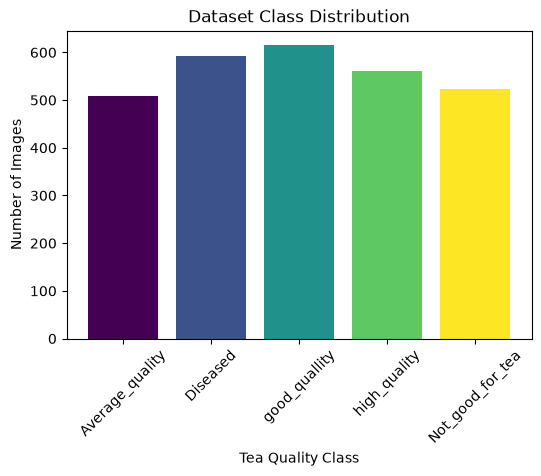

In [5]:
# Class distribution

classes = []
counts = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        classes.append(folder)
        counts.append(len(os.listdir(folder_path)))
colors = plt.cm.viridis(np.linspace(0, 1, len(classes)))
plt.figure(figsize=(6,4))
plt.bar(classes, counts, color=colors)
plt.xticks(rotation=45)
plt.title("Dataset Class Distribution")
plt.xlabel("Tea Quality Class")
plt.ylabel("Number of Images")

plt.show()

Image Inspection

In [8]:
# check for bad images

total_images = 0
corrupted_images = 0

for folder in os.listdir("tea_dataset"):
    folder_path = os.path.join("tea_dataset", folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            total_images += 1
            try:
                img = Image.open(
                    os.path.join(folder_path, file)
                )
                img.verify()
            except Exception:
                corrupted_images += 1
                print("Corrupted:", file)

print(f"Total images: {total_images}")
print(f"Corrupted images: {corrupted_images}")

Total images: 2800
Corrupted images: 0


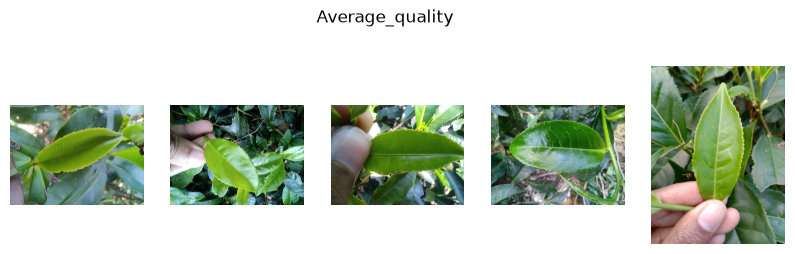

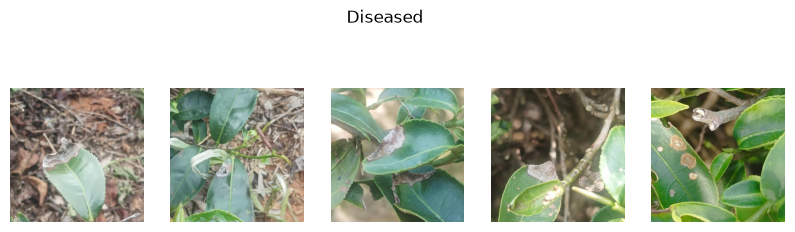

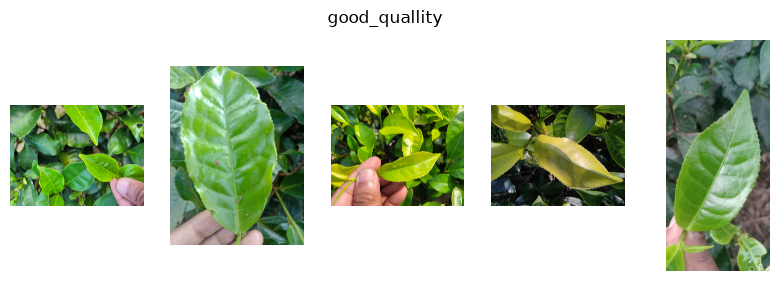

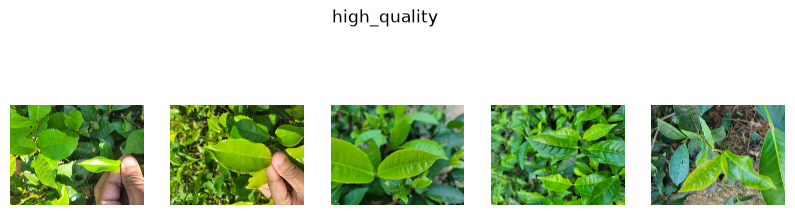

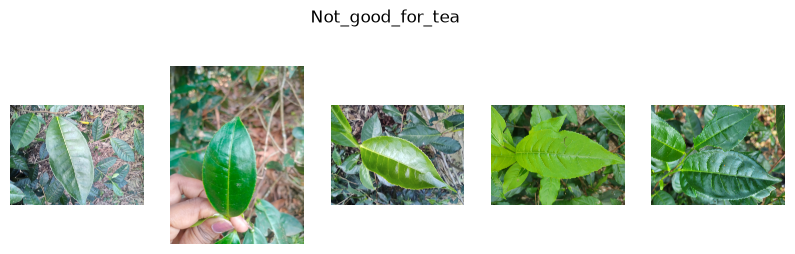

In [7]:
import random
dataset_path = "tea_dataset"

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        plt.figure(figsize=(10,3))

        files = random.sample(
            os.listdir(folder_path),
            min(5, len(os.listdir(folder_path)))
        )
        for i, file in enumerate(files):
            img = Image.open(
                os.path.join(folder_path, file)
            )
            plt.subplot(1,5,i+1)
            plt.imshow(img)
            plt.axis('off')
        plt.suptitle(folder)
        plt.show()
plt.show()

DATA PREPROCESSING

In [25]:
#resize
IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [10]:
#Normalize
rescale=1./255

DATA AUGMENTATION

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.3,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.15,
    brightness_range=[0.8,1.2] #randomly changes the brightness of training images.
)

# should i do 20% or 15%

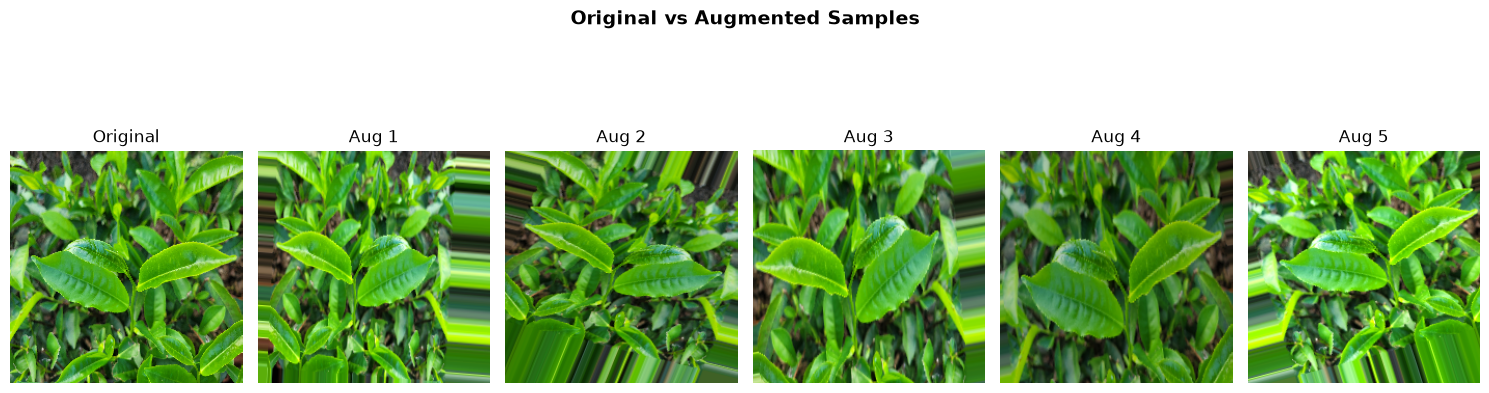

In [41]:
# BEFORE AND AFTER
from tensorflow.keras.utils import load_img, img_to_array

# Load image
img_path = "tea_dataset/high_quality/20231224_160831.jpg"
img = load_img(img_path, target_size=(224,224))
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

train_datagen = ImageDataGenerator(
    #rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

# Create augmented images
aug_iter = train_datagen.flow(img_array, batch_size=1)
plt.figure(figsize=(15,5))
plt.suptitle("Original vs Augmented Samples", fontsize=14, fontweight='bold')

# Original image
plt.subplot(1,6,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

# 5 augmented versions
for i in range(5):
    batch = next(aug_iter)
    aug_img = batch[0].astype("uint8")

    plt.subplot(1,6,i+2)
    plt.imshow(aug_img)
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

LOAD DATA

In [43]:

train_generator = datagen.flow_from_directory(
    "tea_dataset",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical", #TensorFlow converts each class into a one-hot encoded vector. [1, 0, 0, 0, 0] etc
    subset="training",
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    "tea_dataset",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2382 images belonging to 5 classes.
Found 418 images belonging to 5 classes.


BUILD CNN

In [45]:
# Extract leaf patterns
#CNN Architecture

from tensorflow.keras import models,layers

cnn_model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), activation='relu' ),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(5, activation='softmax')
])
cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265,861 (73.49 MB)

 Trainable params: 19,265,861 (73.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#optimizer = Adam(learning_rate=0.001)

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

CALLBACKS

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

TRAIN MODEL

In [33]:
history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 267s 4s/step - accuracy: 0.4937 - loss: 1.1908 - val_accuracy: 0.3923 - val_loss: 1.4400
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 324s 4s/step - accuracy: 0.6633 - loss: 0.8515 - val_accuracy: 0.4019 - val_loss: 1.5191
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 350s 5s/step - accuracy: 0.7238 - loss: 0.7170 - val_accuracy: 0.4139 - val_loss: 1.3183
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 328s 4s/step - accuracy: 0.7527 - loss: 0.6415 - val_accuracy: 0.4928 - val_loss: 1.1339
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 343s 5s/step - accuracy: 0.7620 - loss: 0.6007 - val_accuracy: 0.5024 - val_loss: 1.1998
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - accuracy: 0.7666 - loss: 0.5868 - val_accuracy: 0.5215 - val_loss: 1.3400
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 343s 5s/step - accuracy: 0.7951 - loss: 0.5501 - val_accuracy: 0.4498 - val_loss: 1.2600
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 332s 4s/step - accuracy: 0.7846 - loss: 0.5478 - val_accuracy: 0.5048 - v

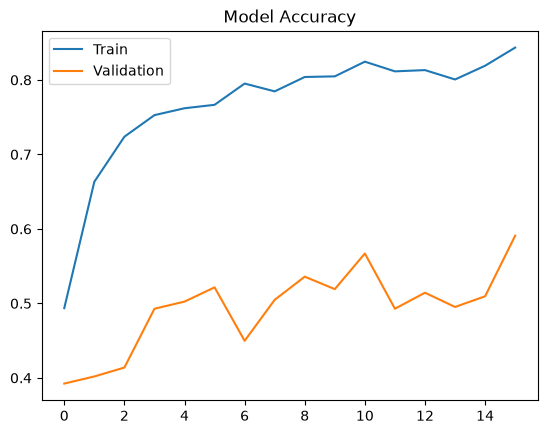

In [34]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend([
    'Train',
    'Validation'
])
plt.title("Model Accuracy")
plt.show()

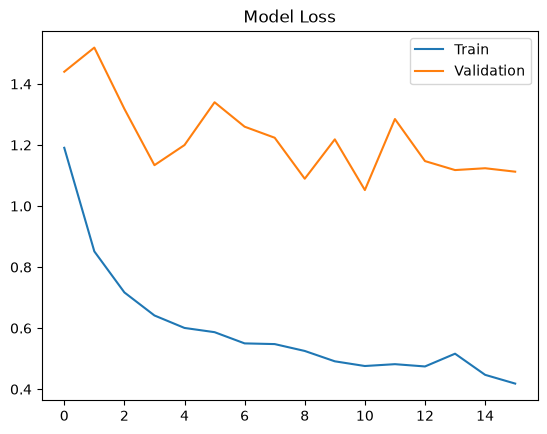

In [35]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend([
    'Train',
    'Validation'
])

plt.title("Model Loss")
plt.show()